Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-3036172381.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lut[i] = np.clip(255 * (cumul_sum / hist_sum), 0, 255).astype(np.uint8)


(0.0, 255.0)

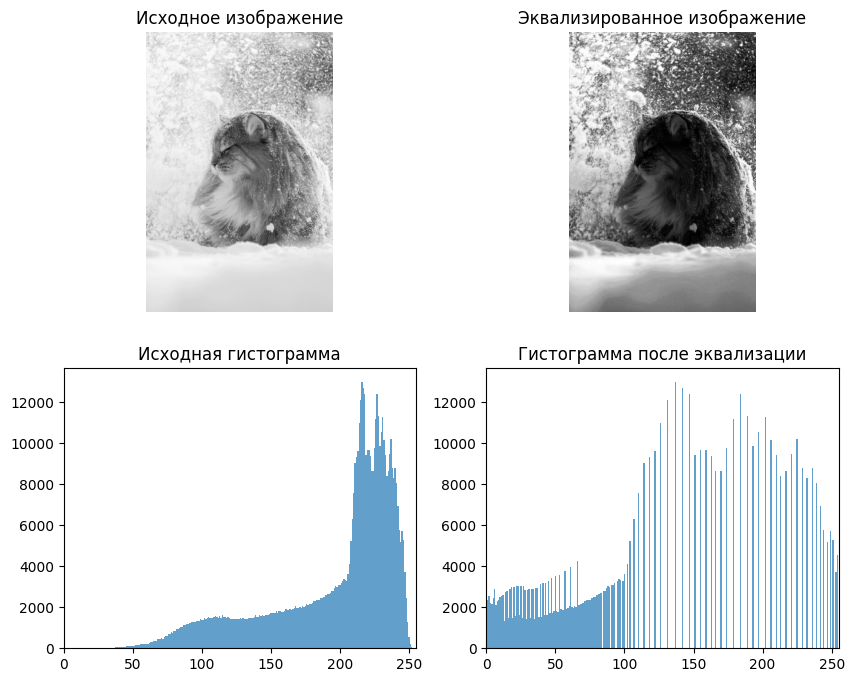

In [27]:
from google.colab import files
from google.colab.patches import cv2_imshow
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/MyDrive/Image_processing/winter_cat.png'
image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

channels = [0]
histSize = [256]
range1 = [0, 256]

def equalize(image):
    # Вычисление гистограммы
    # Количество пикселей в изображении с соответствующей яркостью
    hist = cv2.calcHist([image], channels, None, histSize, range1)

    # Вычисление кумулятивной суммы (CDF)
    # Анализ распределения значений яркости пикселей в гистограмме изображения
    cdf = np.cumsum(hist)

    # Создание LUT по формуле: LUT[i] = 255 * (sum(Hist[1:i]) / sum(Hist[1:255]))
    lut = np.zeros(256, dtype=np.uint8)
    hist_sum = cdf[255]  # sum(Hist[1:255])

    for i in range(256):
        cumul_sum = cdf[i] - hist[0]
        lut[i] = np.clip(255 * (cumul_sum / hist_sum), 0, 255).astype(np.uint8)

    # Применение LUT к изображению
    eq_image = lut[image]

    return eq_image, lut, hist


# Применение эквализации
eq_image, lut, hist_orig = equalize(image)

# Вычисление гистограммы после эквализации
equalize = cv2.calcHist([eq_image], channels, None, histSize, range1)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Исходное изображение")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(eq_image, cmap="gray")
plt.title("Эквализированное изображение")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.bar(range(256), hist_orig.ravel(), alpha=0.7, width=1.0)
plt.title("Исходная гистограмма")
plt.xlim(0, 255)

plt.subplot(2, 2, 4)
plt.bar(range(256), equalize.ravel(), alpha=0.7, width=1.0)
plt.title("Гистограмма после эквализации")
plt.xlim(0, 255)

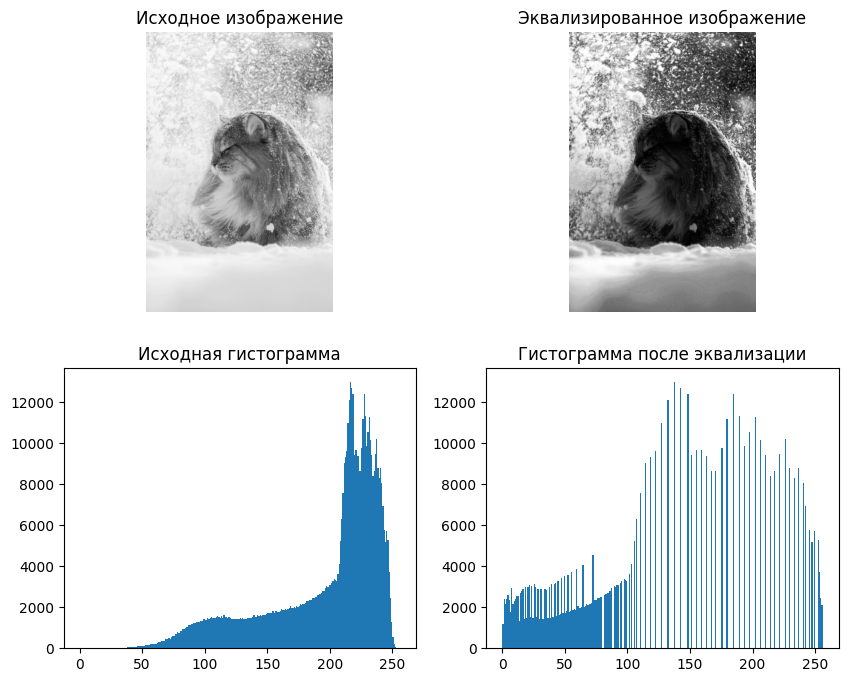

In [28]:
# С помощью OpenCV

image2 = cv2.equalizeHist(image)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Исходное изображение")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(image2, cmap='gray')
plt.title("Эквализированное изображение")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.hist(image.ravel(), bins=256, range=[0,256])
plt.title("Исходная гистограмма")

plt.subplot(2, 2, 4)
plt.hist(image2.ravel(), bins=256, range=[0,256])
plt.title("Гистограмма после эквализации")
plt.show()